# **Preparing Dependancies**

In [58]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from transformers import pipeline
from diffusers import StableDiffusionPipeline
from diffusers import EulerAncestralDiscreteScheduler, DPMSolverMultistepScheduler, DDIMScheduler
from diffusers import StableDiffusionImg2ImgPipeline
from diffusers import StableDiffusionInpaintPipeline
from PIL import Image, ImageDraw, ImageOps, ImageFilter

# **Kriteria 1: Melakukan Image Generation dari Teks (Text-to-Image)**

## **Load Base Pipeline Model**

In [ ]:
pipe_txt2img = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16,
    token="TOKEN"
).to("cuda")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

## **Generate Image**

  0%|          | 0/50 [00:00<?, ?it/s]

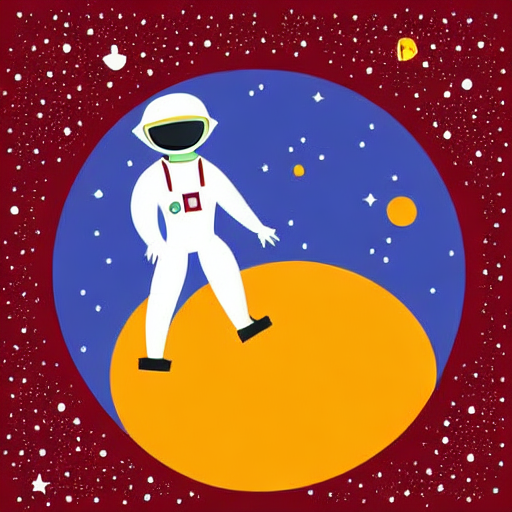

In [60]:
def generate_simple_image(prompt, negative_prompt, seed):
    generator = torch.Generator(device="cuda").manual_seed(seed)
    image = pipe_txt2img(
        prompt=prompt,
        negative_prompt=negative_prompt,
        generator=generator
    ).images[0]
    return image

prompt_ast = "a simple 2D flat vector illustration of an astronaut in a white suit standing on a red planet surface, dark starry sky, a large blue Earth globe in the upper right background, bold clean black outlines, solid flat colors, minimalist cartoon style, 2D art, no shading, high contrast"
negative_prompt_ast = "photorealistic, realistic, photograph, 3d render, messy, blurry, low quality, bad art, ugly, sketch, grainy, unfinished, chromatic aberration"

img_simple = generate_simple_image(prompt_ast, negative_prompt_ast, 222)
img_simple

## **Generate Image with Hyperparameter Configuration**

  0%|          | 0/30 [00:00<?, ?it/s]

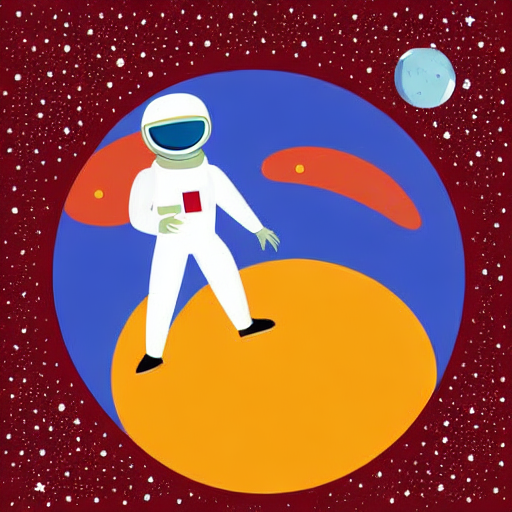

In [61]:
def generate_advanced_image(prompt, negative_prompt, seed, guidance_scale, num_inference_steps):
    generator = torch.Generator(device="cuda").manual_seed(seed)
    image = pipe_txt2img(
        prompt=prompt,
        negative_prompt=negative_prompt,
        guidance_scale=guidance_scale,
        num_inference_steps=num_inference_steps,
        generator=generator
    ).images[0]
    return image

img_adv = generate_advanced_image(prompt_ast, negative_prompt_ast, 222, guidance_scale=7.5, num_inference_steps=30)
img_adv

## **Guidance Scale Comparison**

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

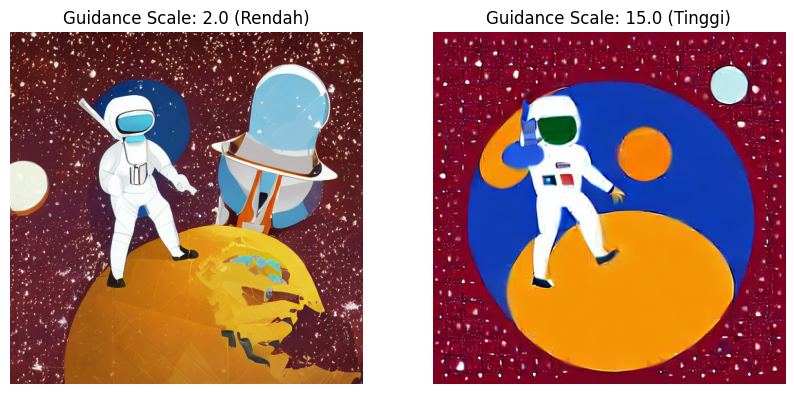

In [62]:
img_low_cfg = generate_advanced_image(prompt_ast, negative_prompt_ast, 222, guidance_scale=2.0, num_inference_steps=30)
img_high_cfg = generate_advanced_image(prompt_ast, negative_prompt_ast, 222, guidance_scale=15.0, num_inference_steps=30)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_low_cfg)
axes[0].set_title("Guidance Scale: 2.0 (Rendah)")
axes[0].axis("off")

axes[1].imshow(img_high_cfg)
axes[1].set_title("Guidance Scale: 15.0 (Tinggi)")
axes[1].axis("off")
plt.show()

### **Guidance Scale Explanation:**

*   **Gambar dengan "Scale" Rendah:**   
*"Gambar yang dihasilkan cenderung mengabaikan prompt asli, komposisinya kurang relevan dengan yang diminta, dan bisa jadi menghasilkan objek yang tidak spesifik karena model diberi kebebasan berlebih."*

*   **Gambar dengan "Scale" Tinggi:**   
*"Gambar sangat ketat mengikuti prompt. Detailnya sangat kuat dan sesuai dengan teks, namun terkadang bisa terlihat terlalu over-saturated, kaku, atau kehilangan nilai estetik alaminya."*

## **Inference Steps Comparison**

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

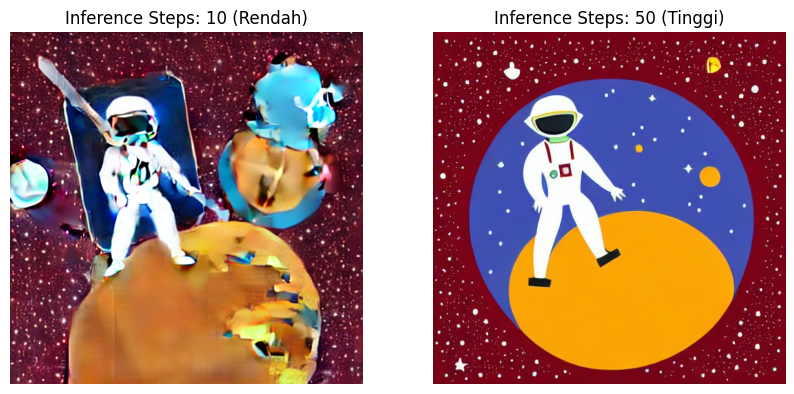

In [63]:
img_low_step = generate_advanced_image(prompt_ast, negative_prompt_ast, 222, guidance_scale=7.5, num_inference_steps=10)
img_high_step = generate_advanced_image(prompt_ast, negative_prompt_ast, 222, guidance_scale=7.5, num_inference_steps=50)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_low_step)
axes[0].set_title("Inference Steps: 10 (Rendah)")
axes[0].axis("off")

axes[1].imshow(img_high_step)
axes[1].set_title("Inference Steps: 50 (Tinggi)")
axes[1].axis("off")
plt.show()

### **Inference Step Explanation:**

*   **Gambar dengan "Step" Rendah:**  
*"Gambar terlihat belum selesai (masih ada noise atau buram). Detail objek tidak terbentuk sempurna dan artefak visual sangat terlihat jelas."*
*   **Gambar dengan "Step" Tinggi:**  
*"Gambar terlihat jauh lebih halus, tajam, dan stabil secara visual. Detail terkecil pada gambar berhasil dirender dengan baik tanpa adanya noise yang mengganggu."*

## **Batch Inference from One Prompt**

  0%|          | 0/30 [00:00<?, ?it/s]

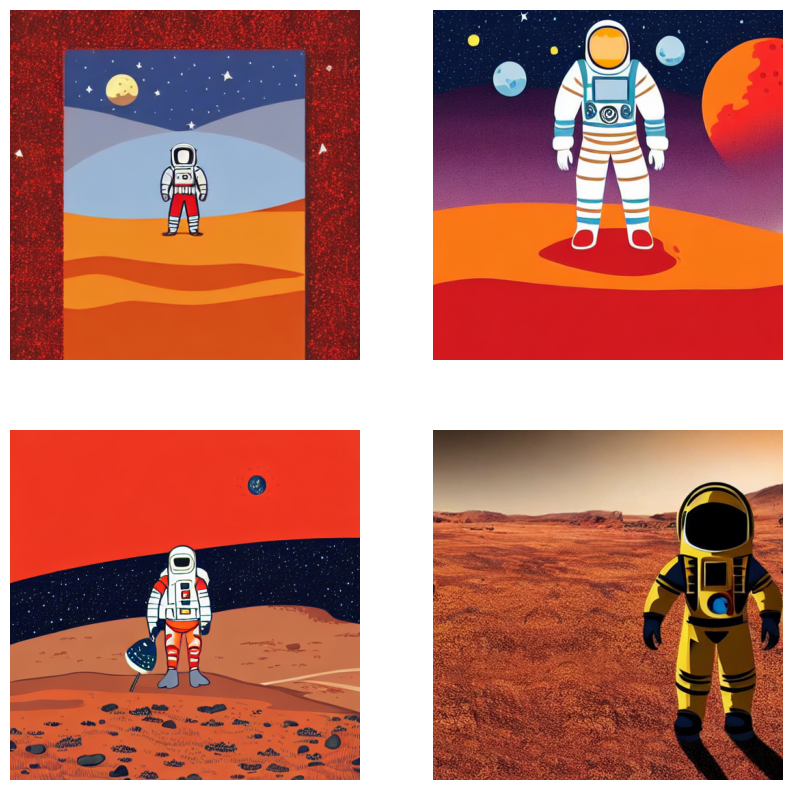

In [64]:
generator = torch.Generator("cuda").manual_seed(222)
prompt = "A high quality flat 2D illustration of a lone astronaut standing on the red dirt surface of Mars, clear black starry space background with the Earth visible in the upper right sky, clean lines, comic book style, vibrant solid colors"
negative_prompt = "photorealistic, realistic, photograph, 3d render, messy, blurry, low quality, bad art, ugly, sketch, grainy, unfinished, chromatic aberration"

batch_images = pipe_txt2img(
    prompt=prompt,
    negative_prompt=negative_prompt,
    num_inference_steps=30,
    guidance_scale=7.5,
    num_images_per_prompt=4,
    generator=generator
).images

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for ax, img in zip(axes.flatten(), batch_images):
    ax.imshow(img)
    ax.axis("off")
plt.show()

## **Load Scheduler**

In [65]:
def load_scheduler(pipe, scheduler_name):
    if scheduler_name == "Euler A":
        pipe.scheduler = EulerAncestralDiscreteScheduler.from_config(pipe.scheduler.config)
    elif scheduler_name == "DPM++":
        pipe.scheduler = DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)
    elif scheduler_name == "DDIM":
        pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)
    return pipe

### **Scheduler Comparation:**

*   **Gambar dengan "Euler A Scheduler":**  
*"Gambar yang dihasilkan cenderung memiliki variasi komposisi yang lebih kreatif dan estetik. Karena Euler Ancestral (Euler A) terus menambahkan sedikit noise pada setiap langkahnya, gambar tidak pernah benar-benar konvergen ke satu titik akhir yang kaku, melainkan terus berevolusi secara halus, membuatnya cocok untuk eksplorasi artistik."*
*   **Gambar dengan "DPM++ Scheduler":**  
*"Gambar yang dihasilkan terlihat sangat tajam, detail, dan fotorealistis. Algoritma DPM++ sangat efisien dan mampu mencapai titik konvergen (hasil akhir yang matang) dengan sangat cepat, sehingga sangat bagus digunakan meskipun dengan jumlah inference steps yang lebih sedikit."*
*   **Gambar dengan "DDIM Scheduler":**  
*"Gambar yang dihasilkan sangat stabil dan konsisten. Scheduler DDIM bersifat deterministik, yang berarti jika kita menggunakan prompt dan seed yang sama, ia akan secara andal merekonstruksi gambar dengan komposisi yang nyaris identik, halus, dan meminimalisir adanya perubahan elemen secara tiba-tiba."*

# **Kriteria 2: Menyempurnakan Gambar Melalui Image-to-Image**

## **Base + Refiner Image Generation**

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

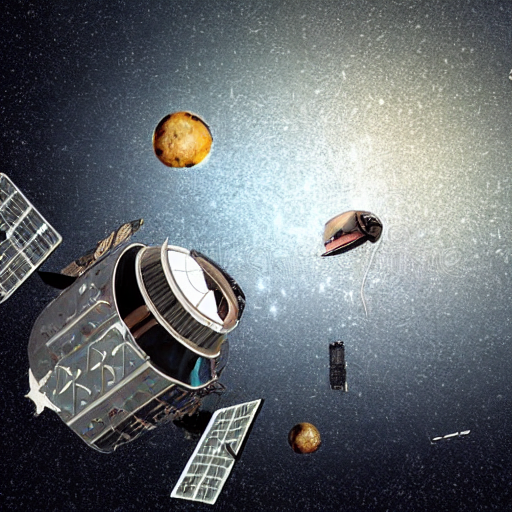

In [66]:
# Base Generation
latent_output = pipe_txt2img(
    prompt="a broken futuristic space satellite crashed on the ground, metallic parts, debris, 2D illustration style",
    num_inference_steps=50,
    output_type="latent",
    denoising_end=0.8
).images

# Refiner Generation
final_image = pipe_txt2img(
    prompt="a broken futuristic space satellite crashed on the ground, metallic parts, debris, 2D illustration style",
    image=latent_output,
    num_inference_steps=50,
    denoising_start=0.8
).images[0]
final_image

## **Inpainting**

### **Load Model Inpainting**

In [ ]:
pipe_inpaint = StableDiffusionInpaintPipeline.from_pretrained(
    "runwayml/stable-diffusion-inpainting",
    torch_dtype=torch.float16,
    token="TOKEN"
).to("cuda")

unet/diffusion_pytorch_model.safetensors not found


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

### **Manual Masking**

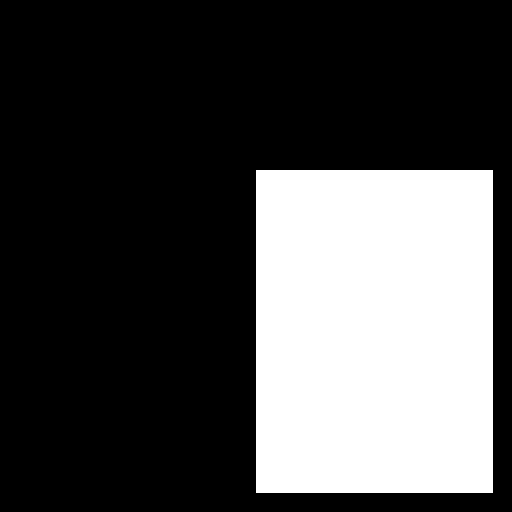

In [68]:
width, height = img_adv.size

mask_image = Image.new("L", (width, height), 0)
draw = ImageDraw.Draw(mask_image)
draw.rectangle((width//2, height//3, width-20, height-20), fill=255)

mask_image

### **Generate**

  0%|          | 0/30 [00:00<?, ?it/s]

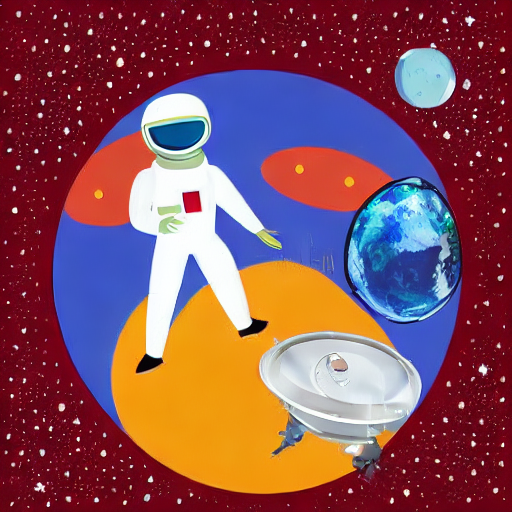

In [69]:
generator_inpaint = torch.Generator(device="cuda").manual_seed(9)
inpaint_prompt = "a broken futuristic space satellite crashed on the ground, metallic parts, debris, 2D illustration style"

inpainted_img = pipe_inpaint(
    prompt=inpaint_prompt,
    image=img_adv,
    mask_image=mask_image,
    num_inference_steps=30,
    guidance_scale=7.5,
    generator=generator_inpaint
).images[0]

inpainted_img

## **Inpainting Menggunakan Automasking**

### **load Model Segmentation Untuk Masking**

In [70]:
segmenter = pipeline("image-segmentation", model="briaai/RMBG-1.4", trust_remote_code=True)

### **Masking with Segmentation Model**

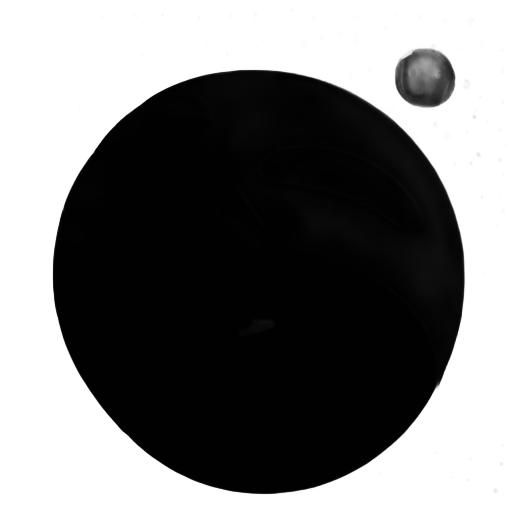

In [71]:
auto_mask_rgba = segmenter(img_adv)
auto_mask = auto_mask_rgba.split()[-1]
auto_mask = ImageOps.invert(auto_mask)

auto_mask

### **Generate**

  0%|          | 0/30 [00:00<?, ?it/s]

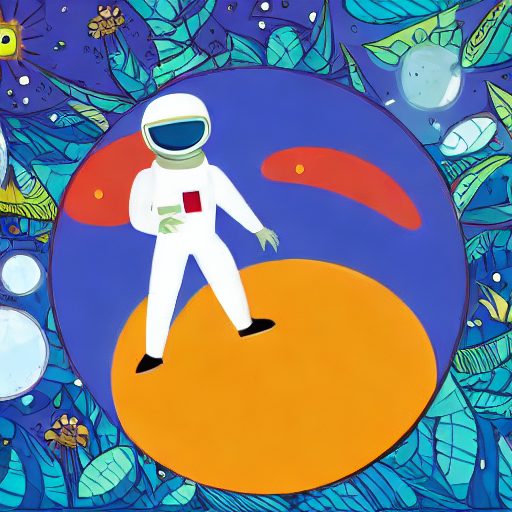

In [72]:
generator_auto = torch.Generator(device="cuda").manual_seed(9)
auto_prompt = "a magical alien landscape, glowing plants, galaxy sky, flat color comic style"

auto_inpainted_img = pipe_inpaint(
    prompt=auto_prompt,
    image=img_adv,
    mask_image=auto_mask,
    num_inference_steps=30,
    guidance_scale=7.5,
    generator=generator_auto
).images[0]

auto_inpainted_img

## **Outpainting**

### **Prepare the Canvas**

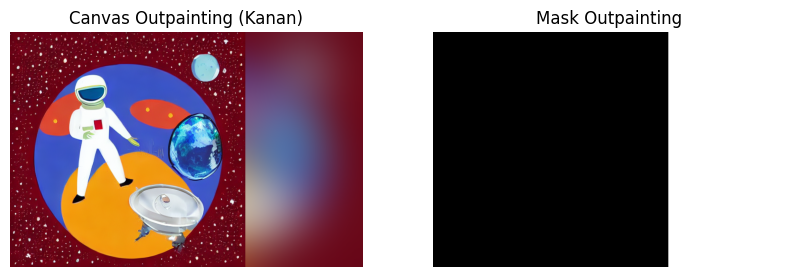

In [73]:
def prepare_outpainting_single_direction(image, direction="right", expand_pixels=128):
    w, h = image.size
    new_w, new_h = w, h

    if direction in ["left", "right"]:
        new_w += expand_pixels
    else:
        new_h += expand_pixels

    # Membuat canvas baru dengan memberikan efek blur dari gambar asli
    bg = image.resize((new_w, new_h), resample=Image.BICUBIC)
    bg = bg.filter(ImageFilter.GaussianBlur(radius=50))
    canvas = bg.copy()

    # Menentukan posisi paste berdasarkan arah
    paste_x, paste_y = 0, 0
    if direction == "right": paste_x = 0
    elif direction == "left": paste_x = expand_pixels
    elif direction == "bottom": paste_y = 0
    elif direction == "top": paste_y = expand_pixels

    canvas.paste(image, (paste_x, paste_y))

    # Membuat Mask (Putih = area baru yang akan di-generate, Hitam = gambar asli)
    mask = Image.new("L", (new_w, new_h), 255)
    inner_box = Image.new("L", (w, h), 0)
    mask.paste(inner_box, (paste_x, paste_y))

    return canvas, mask

# Memperluas ke arah kanan pada gambar inpainted sebelumnya
outpaint_canvas, outpaint_mask = prepare_outpainting_single_direction(inpainted_img, direction="right", expand_pixels=256)

# Menampilkan kanvas dan mask
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(outpaint_canvas)
axes[0].set_title("Canvas Outpainting (Kanan)")
axes[0].axis("off")
axes[1].imshow(outpaint_mask, cmap="gray")
axes[1].set_title("Mask Outpainting")
axes[1].axis("off")
plt.show()

### **Generate**

  0%|          | 0/30 [00:00<?, ?it/s]

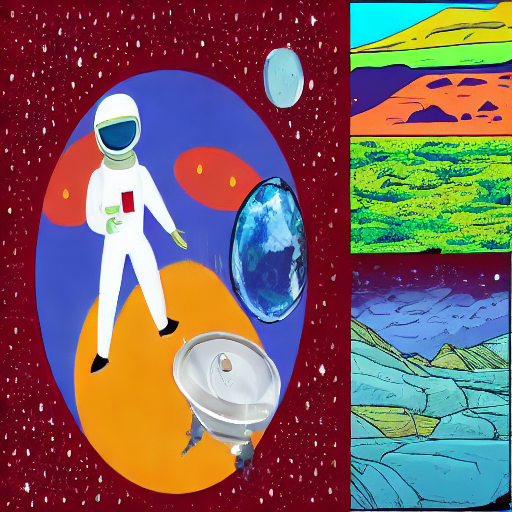

In [74]:
generator_outpaint = torch.Generator(device="cuda").manual_seed(9)
outpaint_prompt = "martian landscape, red rocks, flat color comic style, expansive background"

outpainted_img = pipe_inpaint(
    prompt=outpaint_prompt,
    image=outpaint_canvas,
    mask_image=outpaint_mask,
    num_inference_steps=30,
    guidance_scale=7.5,
    generator=generator_outpaint
).images[0]

outpainted_img

## **Outpainting Zoom Out**

### **Prepare Canvas for Zoom Out**

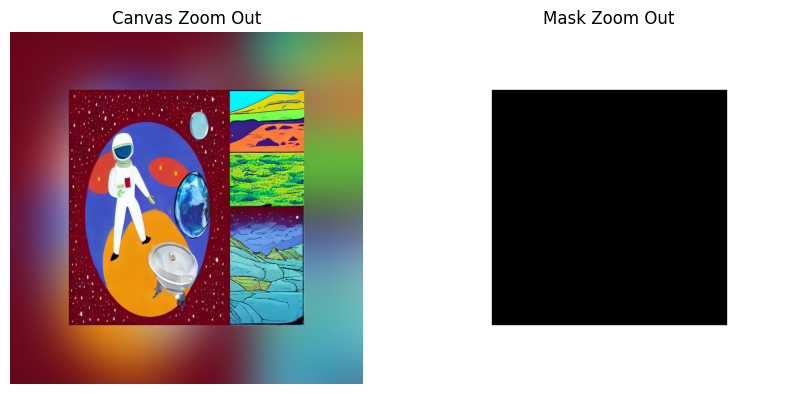

In [75]:
def prepare_outpainting_zoom_out(image, expand_pixels=128):
    w, h = image.size
    new_w = w + (expand_pixels * 2)
    new_h = h + (expand_pixels * 2)

    # Resolusi harus kelipatan 8 agar tidak error pada Stable Diffusion
    new_w -= (new_w % 8)
    new_h -= (new_h % 8)

    # Blur background
    bg = image.resize((new_w, new_h), resample=Image.BICUBIC)
    bg = bg.filter(ImageFilter.GaussianBlur(radius=50))
    canvas = bg.copy()

    # Paste gambar asli di tengah (center)
    paste_x = (new_w - w) // 2
    paste_y = (new_h - h) // 2
    canvas.paste(image, (paste_x, paste_y))

    # Masking (Putih keliling, Hitam di tengah)
    mask = Image.new("L", (new_w, new_h), 255)
    inner_box = Image.new("L", (w, h), 0)
    mask.paste(inner_box, (paste_x, paste_y))

    return canvas, mask

zoom_canvas, zoom_mask = prepare_outpainting_zoom_out(outpainted_img, expand_pixels=128)

# Menampilkan kanvas dan mask zoom out
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(zoom_canvas)
axes[0].set_title("Canvas Zoom Out")
axes[0].axis("off")
axes[1].imshow(zoom_mask, cmap="gray")
axes[1].set_title("Mask Zoom Out")
axes[1].axis("off")
plt.show()

### **Generate**

  0%|          | 0/30 [00:00<?, ?it/s]

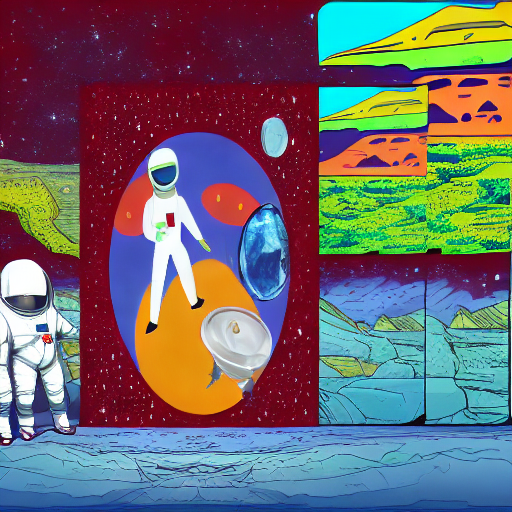

In [76]:
generator_zoom = torch.Generator(device="cuda").manual_seed(9)
zoom_prompt = "wide angle view of astronaut on mars with broken satellite, vast alien landscape, earth in space, flat color comic style, 8k"

zoom_out_img = pipe_inpaint(
    prompt=zoom_prompt,
    image=zoom_canvas,
    mask_image=zoom_mask,
    num_inference_steps=30,
    guidance_scale=7.5,
    generator=generator_zoom
).images[0]

zoom_out_img